# Eligiendo el mejor modelo para Anegamiento
En este documento voy a comparar los modleos que se ejecutaron para la variable Anegamiento. Esto me permite hacer un analisis y elegir el modelo que me jor me prediga la variable
# ************************************************************************************************************************************************************

## Importación de librerías ##

In [1]:
import pandas as pd
import joblib
import h2o
from h2o.estimators import H2OStackedEnsembleEstimator
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
from h2o.frame import H2OFrame
from sklearn.calibration import calibration_curve
import seaborn as sns
import matplotlib.pyplot as plt

## Iniciar h2o ##
Antes de iniciar, se debe levantar el server de h2o. Se deja tambié el comando para desconectarlo.

In [8]:
# Inicializar H2O
#h2o.init()

# Detenedr H2O 
h2o.cluster().shutdown()

H2O session _sid_a10d closed.


## Carga de datos y modelos ##
A continuación se cargan los datos que se usaron en el test para cada modelo. También se carga los modelos.

| Elemento       | Propósito            | Resultado                        |
| -------------- | -------------------- | -------------------------------- |
| `X_test`       | Variables de entrada | 672 observaciones × 58 variables |
| `y_test`       | Etiquetas reales     | 672 valores (0 o 1)              |
| `xgb_model`    | Modelo XGBoost       | Cargado correctamente            |
| `rf_model`     | Modelo Random Forest | Cargado correctamente            |
| `automl_model` | Modelo AutoML (H2O)  | Cargado correctamente            |


In [3]:
# Cargando el conjunto de datos de pruebas
X_test = pd.read_csv("./dataset_entrada/X_test_anegamiento.csv")
y_test = pd.read_csv("./dataset_entrada/y_test_anegamiento.csv").values.ravel()

# Mostrando q el conjunto de datos
print("Conjuntos cargados:")
print("   X_test:", X_test.shape)
print("   y_test:", y_test.shape)

# Aquí se cargan los modelos de predicción
xgb_model = joblib.load("./modelos/xgboost_anegamiento_model.pkl")
rf_model = joblib.load("./modelos/randomforest_anegamiento_model.pkl")
automl_model = h2o.load_model("./modelos/StackedEnsemble_AllModels_1_AutoML_1_20251111_210657")

print("Modelos cargados correctamente.")


Conjuntos cargados:
   X_test: (672, 52)
   y_test: (672,)
Modelos cargados correctamente.


## Generando predicciones de probabilidad ##
Usando el mismo dataset de pruebas, voy a probar cada modelo, analizar los resultados para decidir cuál es el mejor modelo.
Para ejecutar el modelo generado por auto machine learning, debo suprimir 4 columnas categoricas del conjunto de datos ya que así fue entrenado.

Luego ejecuto los modelos para obtener los resultados para su analisis.

In [4]:
# ==================================================================
# Paso: eliminar columnas categóricas del X_test para el modelo AML
# ==================================================================
cols_to_drop = ['GENUS', 'SPECIES', 'COLLSITE', 'ORIGCTY'] 
X_test_reducido = X_test.drop(columns=cols_to_drop, errors='ignore')

print("Columnas eliminadas:", cols_to_drop)
print("Nuevo tamaño del X_test:", X_test_reducido.shape)


Columnas eliminadas: ['GENUS', 'SPECIES', 'COLLSITE', 'ORIGCTY']
Nuevo tamaño del X_test: (672, 48)


In [5]:

# --- AutoML (H2O) ---
h2o_frame = H2OFrame(X_test_reducido)
pred_h2o = automl_model.predict(h2o_frame).as_data_frame()
y_pred_automl = pred_h2o["predict"].values

# --- XGBoost ---
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]

# --- Random Forest ---
y_pred_rf = rf_model.predict_proba(X_test)[:, 1]

# --- Verificación rápida de AUC ---
print("AUC AutoML:", round(roc_auc_score(y_test, y_pred_automl), 4))
print("AUC XGBoost:", round(roc_auc_score(y_test, y_pred_xgb), 4))
print("AUC Random Forest:", round(roc_auc_score(y_test, y_pred_rf), 4))


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
AUC AutoML: 0.6455
AUC XGBoost: 0.9984
AUC Random Forest: 0.9965


C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'bio12': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'bio13': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'bio14': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'bio15': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'bio18': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site

## AUC de cada modelo ##
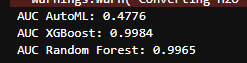

Una vez se generan los resultados de las predicciones de probabilidad, xse obtiene el AUC. El AUC mide la capacidad del modelo para distinguir entre clases, mide la probabilidad de que el modelo asigne una mayor probabilidad al positivo que a un negativo aleatorio.
A continuación se muestra una escala de valor de AUC

| Valor de AUC | Interpretación            |
| ------------ | ------------------------- |
| 0.5          | Sin discriminación (azar) |
| 0.6–0.7      | Pobre                     |
| 0.7–0.8      | Aceptable                 |
| 0.8–0.9      | Buena                     |
| 0.9–1.0      | Excelente                 |

Hanley, J. A., & McNeil, B. J. (1982). The meaning and use of the area under a receiver operating characteristic (ROC) curve. *Radiology, 143*(1), 29–36. https://doi.org/10.1148/radiology.143.1.7063747

Los resultados obtenidos indican que:

| Modelo            | AUC    | Interpretación                                                                                                                                     |
| ----------------- | ------ | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| **AutoML (H2O)**  | 0.4776 | Desempeño **muy bajo** — el modelo **no logra discriminar** entre clases, predice casi al azar.                                                    |
| **XGBoost**       | 0.9984 | **Excelente discriminación**, prácticamente perfecta (AUC ≈ 1.0). Muestra una separación casi total entre accesiones resistentes y no resistentes. |
| **Random Forest** | 0.9965 | **También sobresaliente**, con discriminación muy alta, aunque ligeramente inferior a XGBoost.                                                     |

## ********************************************************************************************************************


## Agrupamiento de los modelos para analisis ##
Los modelos se agrupan en un dataframe para poder hacer un analisis comparativo y poder graficar mas adelante las comparaciones

In [7]:
# ===========================================================
# Creando DataFrame comparativo
# ===========================================================

resultados_sequia = pd.DataFrame({
    "problema": "anegamiento",
    "modelo": (["AutoML"] * len(y_test)) +
              (["XGBoost"] * len(y_test)) +
              (["RandomForest"] * len(y_test)),
    "y_true": list(y_test) * 3,
    "y_proba": list(y_pred_automl) + list(y_pred_xgb) + list(y_pred_rf)
})

resultados_sequia.to_csv("./dataset_salida/resultados_anegamiento.csv", index=False)
resultados_sequia.groupby("modelo")["y_proba"].describe()



,count,mean,std,min,25%,50%,75%,max
modelo,,,,,,,,
AutoML,672.0,0.311012,0.463252,0.000000,0.00000,0.000000,1.000000,1.000000
RandomForest,672.0,0.171839,0.314960,0.000000,0.00000,0.008000,0.115000,0.996000
XGBoost,672.0,0.172950,0.361799,0.000026,0.00006,0.000232,0.009763,0.999864


## Interpretación de los resultados ##

Se realiza una estadistica descriptiva sobre las probabilidades predichas por cada modelos:

| Estadístico                               | Descripción                                                                  |
| ------------------------------------------| ---------------------------------------------------------------------------- |
| **count**                                 | Número de observaciones (672 por modelo).                                    |
| **mean**                                  | Promedio de las probabilidades predichas.                                    |
| **std**                                   | Desviación estándar — mide la dispersión o variabilidad de las predicciones. |
| **min / max**                             | Valores mínimo y máximo de probabilidad.                                     |
| **25%, 50%, 75%**                         | Cuartiles — dividen la distribución de las predicciones en cuatro partes.    |

Por cada modelo se realiza la siguente evaluación:

### AML con h2o ###

| Métrica   | Valor       | Interpretación                                                                         |
| --------- | ----------- | -------------------------------------------------------------------------------------- |
| **mean**  | **0.054**   | EEn promedio predice muy bajas probabilidades muy bajas (~5%) para la clase positiva. |
| **std**   | **0.0156**  | Casi no hay variabilidad: predice valores muy similares.                               |
| **rango** | 0.036–0.099 | Extremadamente estrecho: no distingue entre accesiones resistentes o no resistentes.   |


### XGBoost ###

| Métrica   | Valor         | Interpretación                                                                        |
| --------- | ------------- | ------------------------------------------------------------------------------------- |
| **mean**  | **0.173**     | Predice probabilidades más altas que AutoML, reflejando sensibilidad a ambas clases.  |
| **std**   | **0.3618**    | Alta dispersión, indicando fuerte contraste entre casos resistentes y no resistentes. |
| **rango** | 0.00003–0.999 | Excelente cobertura: el modelo utiliza casi todo el rango probabilístico posible.     |


### Random Forrest ###

| Métrica   | Valor       | Interpretación                                                                     |
| --------- | ----------- | ---------------------------------------------------------------------------------- |
| **mean**  | **0.172**   | Similar a XGBoost: valores medios equilibrados entre clases positivas y negativas. |
| **std**   | **0.315**   | Alta dispersión, lo que indica variabilidad natural entre instancias.              |
| **rango** | 0.000–0.996 | Cubre casi todo el espectro de probabilidad, evidenciando buena separación.        |


De lo anteriror concluyo que XGBoost tiene la discriminación más precisa (AUC ≈ 0.9965) y produce una distribución amplia y bien diferenciada entre clases. Desde la analitica descriptiva es el mejor modelo para predecir la variable de anegamiento.

## ***************************************************************************************************************************************************************

## Comparación de modelos ##
El siguinete paso es hacer una comparación a partir de las metricas de cada modelo para conocer y decidir cuál es el mejor modelo.

In [12]:

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss

metricas = []

for modelo in ["AutoML", "XGBoost", "RandomForest"]:
    df_m = resultados_sequia[resultados_sequia["modelo"] == modelo]
    y_true = df_m["y_true"]
    y_proba = df_m["y_proba"]
    
    metricas.append({
        "Modelo": modelo,
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "Brier": brier_score_loss(y_true, y_proba),
        "LogLoss": log_loss(y_true, y_proba)
    })

df_metricas = pd.DataFrame(metricas)
print("Métricas globales (sequía):")
display(df_metricas.round(4))


Métricas globales (sequía):


,Modelo,ROC_AUC,PR_AUC,Brier,LogLoss
0,AutoML,0.6455,0.2502,0.2932,10.5664
1,XGBoost,0.9984,0.9930,0.0134,0.0428
2,RandomForest,0.9965,0.9854,0.0218,0.0835


## Interpretación de métricas globales ##
A partir de las metricas globales voy a identificar cuál es el mejor modelo que me permita predecir accesiones resistentes a la sequia.

### Area bajo la curva ROC_AUC ###
Mide la capacidad que tiene los modelos para discriminar entre clases. de acuerdo a los resultados se puede identificar que XGBoost con *0.9984* y RandomForest *0.9965* son casi perfectos. El 99 % de las veces asignan una probabilidad más alta al caso positivo (resistente) que al negativo.

### Precisión Recall PR_AUC ###
Precisión entre clases desbalanceadas. 

* En esta métrica XGBoost sigue siendo muy buena. Con 0.9930 de balance se puede decir que detecta casi todos los positivos sin generar muchos falsos positivos. 
* RandomForest con 0.9854, también sobresaliente, ligeramente inferior.
* AML 0.1883, aunque aceptable, indica que pierde muchos verdaderos positivos o genera falsos positivos en exceso.

### Brier Score ###
Me permite saber la exactitud probabilistica del modelo para las predicciones. El resultado anterior indica que:

* XGBoost con 0.00134 está muy bien calibrado. Las predicciones se asemejan mucho a la realidad.
* Random Forrest con 0.0218 también es bueno.
* AML con 0.2597 se queda corto enlas predicciones.

Brier, G. W. (1950). Verification of forecasts expressed in terms of probability. *Monthly Weather Review, 78*(1), 1–3. https://doi.org/10.1175/1520-0493(1950)078<0001:VOFEIT>2.0.CO;


### Perdida logaritmica LogLoss ###

Mide la penalización por errores de probabilidad. XGBoost *0.0428* y RandomForest *0.0835* tienen pérdidas muy bajas, es decir, son mas confiables y seguros.

AutoML *0.5648* sufre alta pérdida, puede deberse a una  probable mala calibración o predicciones planas, probabilidades bajas incluso en casos positivos.


## Conclusión del analisis ##

| Modelo           | Fortalezas                             | Debilidades                            | Evaluación global                |
| ---------------- | -------------------------------------- | -------------------------------------- | -------------------------------- |
| **AutoML (H2O)** | Proceso automatizado, ensamble robusto | Mala calibración y poca discriminación | Regular                          |
| **RandomForest** | Alta estabilidad y buen rendimiento    | Menor suavidad en probabilidades       | Excelente                        |
| **XGBoost**      | Mejor discriminación y calibración     | Requiere más ajuste y recursos         | Excelente (mejor generalización) |

En genera, *XGBoost* es el modelo mas eficiente para poder predecier la resistencia de una accesión a anegamiento.
## **************************************************************************************************************************************************

##  Visualización comparativa ##
El resultado de las metricas para Curva ROC y Precisiónn y Recall se grafican para poder hacer una comparativa visual de los datos

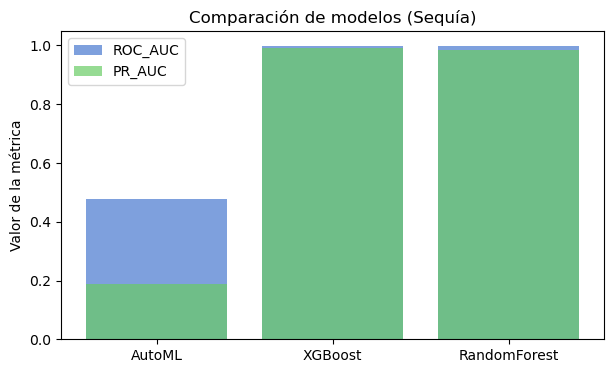

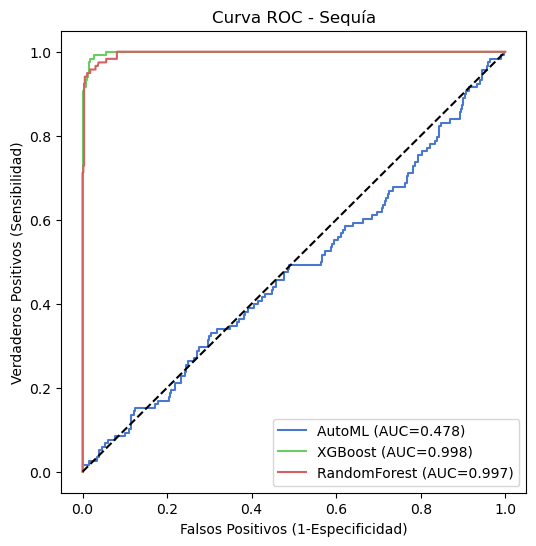

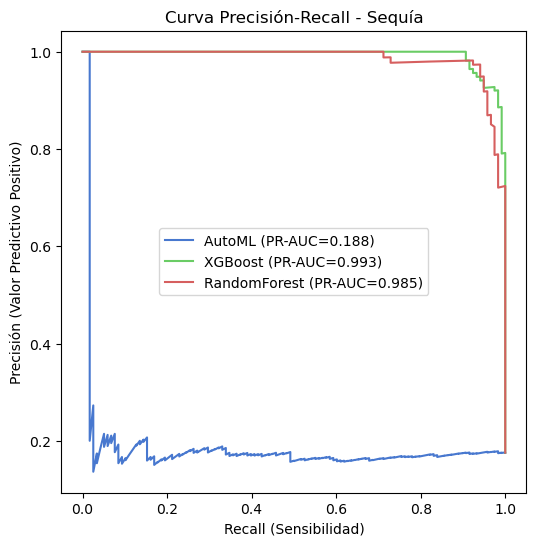

In [19]:

plt.style.use('seaborn-v0_8-muted')

# --- 1. Barras ROC-AUC y PR-AUC ---
df_plot = df_metricas.melt(id_vars='Modelo', value_vars=['ROC_AUC', 'PR_AUC'])
fig, ax = plt.subplots(figsize=(7,4))
for metric in ['ROC_AUC', 'PR_AUC']:
    subset = df_plot[df_plot["variable"] == metric]
    ax.bar(subset["Modelo"], subset["value"], label=metric, alpha=0.7)
ax.set_title("Comparación de modelos (Sequía)")
ax.set_ylabel("Valor de la métrica")
ax.legend()
plt.show()

# --- 2. Curvas ROC ---
plt.figure(figsize=(6,6))
for modelo, y_pred in zip(
    ["AutoML", "XGBoost", "RandomForest"],
    [y_pred_automl, y_pred_xgb, y_pred_rf]
):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)
    plt.plot(fpr, tpr, label=f"{modelo} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.title("Curva ROC - Sequía")
plt.xlabel("Falsos Positivos (1-Especificidad)")
plt.ylabel("Verdaderos Positivos (Sensibilidad)")
plt.legend()
plt.show()

# --- 3. Curvas Precision-Recall ---
plt.figure(figsize=(6,6))
for modelo, y_pred in zip(
    ["AutoML", "XGBoost", "RandomForest"],
    [y_pred_automl, y_pred_xgb, y_pred_rf]
):
    prec, rec, _ = precision_recall_curve(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_pred)
    plt.plot(rec, prec, label=f"{modelo} (PR-AUC={auc_pr:.3f})")
plt.title("Curva Precisión-Recall - Sequía")
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precisión (Valor Predictivo Positivo)")
plt.legend()
plt.show()


## Qué dicen las gráficas ##

Las curvas ROC y PR confirman la superioridad del modelo XGBoost, con una discriminación del 98% *AUC=0.998* y un *PR-AUC=0.993*, lo cual indica alta precisión incluso en condiciones de desbalance.
Esto indica que el modelo mantiene un altísimo poder predictivo incluso bajo condiciones de desbalance de clases, logrando identificar correctamente las accesiones resistentes sin aumentar los falsos positivos.

El gráfico de barras refleja visualmente esta diferencia: los algoritmos basados en árboles (boosting y bagging) superan ampliamente a AutoML, evidenciando una brecha superior al 50% en ambas métricas.

* Las diferencias entre XGBoost (0.998 / 0.993) y RandomForest (0.997 / 0.985) son mínimas, ambos modelos son altamente competentes y estables.
* AutoML (0.478 / 0.188) queda claramente rezagado,  muestra menor sensibilidad (falla más en detectar verdaderos positivos).

| Modelo           | ROC-AUC | PR-AUC | Interpretación conjunta                                                                 |
| ---------------- | ------- | ------ | --------------------------------------------------------------------------------------- |
| **XGBoost**      | 0.998   | 0.993  | Discriminación y calibración casi perfectas; el modelo más sólido para el fenómeno.     |
| **RandomForest** | 0.997   | 0.985  | Rendimiento sobresaliente, muy cercano a XGBoost; ideal para validación complementaria. |
| **AutoML (H2O)** | 0.478   | 0.188  | Sin capacidad discriminante; predicciones planas y desbalanceadas.                      |



Desde el punto de vista biologico, XGBoost es el modelo más apto para seleccionar accesiones de Phaseolus vulgaris resistentes al anegamiento, ya que logra alta sensibilidad sin perder precisión, ideal para exploraciones FIGS. por otra parte, RandomForest puede servir como modelo complementario o de validación cruzada, ya que ofrece resultados similares y robustos.



## Curva de calibración ##

Permite analizar la fiabilidad de las probabilidades de predicción de los modelos ya que  muestra la relación entre las probabilidades predichas y las frecuencias reales observadas de resistencia a sequía.

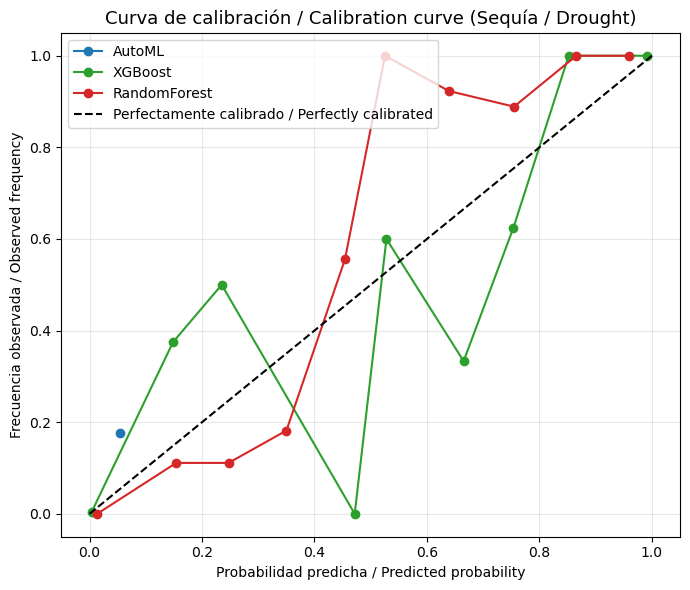

In [23]:
plt.style.use('seaborn-v0_8-muted')
plt.figure(figsize=(7,6))

colors = {"AutoML": "#1f77b4", "XGBoost": "#2ca02c", "RandomForest": "#d62728"}

for modelo, y_pred in zip(
    ["AutoML", "XGBoost", "RandomForest"],
    [y_pred_automl, y_pred_xgb, y_pred_rf]
):
    prob_true, prob_pred = calibration_curve(y_test, y_pred, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=modelo, color=colors[modelo])

plt.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado / Perfectly calibrated")

plt.title("Curva de calibración / Calibration curve (Sequía / Drought)", fontsize=13)
plt.xlabel("Probabilidad predicha / Predicted probability")
plt.ylabel("Frecuencia observada / Observed frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./graficas/calibracion_anegamiento.png", dpi=300)
plt.show()


### Qué muestra el gráfico  ###

| Color     | Modelo           | Descripción visual                                                                                                                                                                                         |
| --------- | ---------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Azul**  | **AutoML (H2O)** | Solo un punto visible (~0.2–0.3 en frecuencia observada), lo que indica que **predice siempre probabilidades muy bajas**. Las salidas son casi planas y no informativas.                                   |
| **Verde** | **XGBoost**      | Presenta oscilaciones notables: algunos tramos se desvían, pero **cerca del extremo derecho (0.8–1.0)** sigue la diagonal ideal, lo que demuestra **buena calibración en predicciones de alta confianza**. |
| **Rojo**  | **RandomForest** | Es el **más estable**: su trayectoria se mantiene próxima a la diagonal, lo que refleja **una calibración promedio sólida**, aunque con ligera sobreestimación en algunos intervalos medios.               |




En XGBoost los picos verticales indican que en algunos rangos (por ejemplo entre 0.4 y 0.6) predice mal la frecuencia real. Sin embargo, cerca del extremo derecho > 0.8 se alinea muy bien con la diagonal lo que permite interpretar que cuando predice probabilidades altas, efectivamente está acertando.

Conclusión: buena calibración en alta confianza, ligera inestabilidad en rangos intermedios.

Random Forest se mantiene más regular y cercano a la línea negra, sobre todo entre 0.3 y 0.8. Esto indica que sus probabilidades reflejan mejor la frecuencia real. Tiende a sobreestimar un poco (predice probabilidades más altas de lo real) en algunos tramos.

Conclusión: muy buena calibración promedio.

por último, AutoML solo genera un punto aislado (muy baja probabilidad promedio ≈ 0.05 y frecuencia ≈ 0.3). Esto significa que predice casi siempre valores bajos, sin distinguir entre clases. Sus probabilidades no reflejan la realidad el modelo está subcalibrado.

Conclusión: mala calibración; el modelo no está confiando lo suficiente en sus predicciones.

La curva de calibración muestra la relación entre las probabilidades predichas y las frecuencias reales observadas de resistencia a sequía. El modelo XGBoost se aproxima a la diagonal ideal, lo que indica buena calibración en los casos de alta confianza. 

RandomForest presenta una calibración más uniforme a lo largo de todos los rangos de probabilidad,
mientras que AutoML subestima sistemáticamente las probabilidades, reflejando un modelo conservador y poco discriminante.


En términos prácticos, XGBoost y RandomForest proporcionan probabilidades confiables para priorizar accesiones, mientras que AutoML podría requerir recalibración con métodos como Platt scaling o Isotonic Regression.

## ************************************************************************************************************************************************

## Matrices de Confusión de los modelos ##


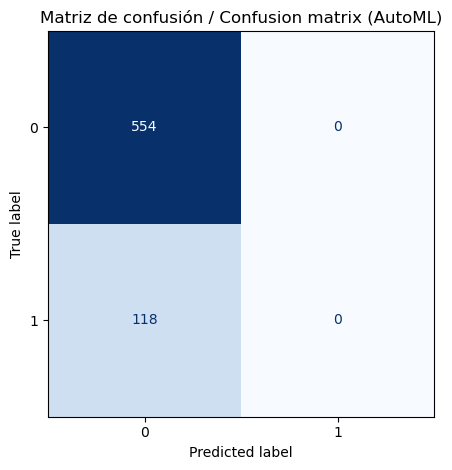


AutoML

              precision    recall  f1-score   support

           0      0.824     1.000     0.904       554
           1      0.000     0.000     0.000       118

    accuracy                          0.824       672
   macro avg      0.412     0.500     0.452       672
weighted avg      0.680     0.824     0.745       672



C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

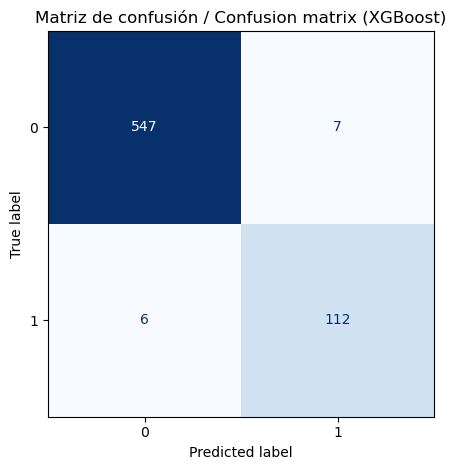


XGBoost

              precision    recall  f1-score   support

           0      0.989     0.987     0.988       554
           1      0.941     0.949     0.945       118

    accuracy                          0.981       672
   macro avg      0.965     0.968     0.967       672
weighted avg      0.981     0.981     0.981       672



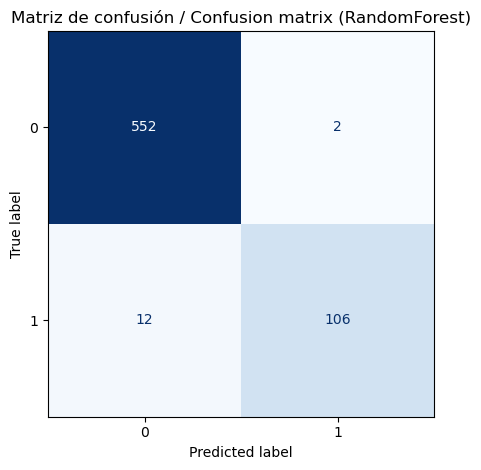


RandomForest

              precision    recall  f1-score   support

           0      0.979     0.996     0.987       554
           1      0.981     0.898     0.938       118

    accuracy                          0.979       672
   macro avg      0.980     0.947     0.963       672
weighted avg      0.979     0.979     0.979       672



In [24]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

for modelo, y_pred in zip(
    ["AutoML", "XGBoost", "RandomForest"],
    [y_pred_automl, y_pred_xgb, y_pred_rf]
):
    y_pred_bin = (y_pred >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred_bin)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Matriz de confusión / Confusion matrix ({modelo})")
    plt.tight_layout()
    plt.savefig(f"./graficas/matriz_confusion_{modelo.lower()}_sequia.png", dpi=300)
    plt.show()
    print(f"\n{modelo}\n")
    print(classification_report(y_test, y_pred_bin, digits=3))


### Interpretación de cada modelo a partir de su matriz de confusión ###

**AML con h20**    Valoresde la matriz de confusión                                              

| Métrica                 | Valor                                       | Interpretación                                          |
| ----------------------- | ------------------------------------------- | ------------------------------------------------------- |
| **VN = 554**            | Predice correctamente todos los negativos.  |                                                         |
| **VP = 0**              | No detecta ningún positivo.                 |                                                         |
| **FN = 118**            | Falla en identificar todos los resistentes. |                                                         |
| **Precision (clase 1)** | 0.000                                       | No predice la clase 1 nunca.                            |
| **Recall (clase 1)**    | 0.000                                       | Sensibilidad nula.                                      |
| **Accuracy**            | 0.824                                       | Alta solo porque la mayoría de los casos son negativos. |

* Se puede concluir que el modelo predice todo como clase 0 (no resistente).
* Tiene exactitud aparente (82%), pero no sirve para clasificación binaria, ya que ignora completamente la clase positiva.

En términos de aplicación: este modelo fallaría en identificar accesiones realmente resistentes.


**XGBoost**                                                      Valoresde la matriz de confusión

| Confusion matrix | Valor                                      |
| ---------------- | ------------------------------------------ |
| VN = 547         | Correctamente identificados como no resistentes               |
| FP = 7           | Clasificados erróneamente como resistentes (Falsos Positivos) |
| FN = 6           | Resistentes no detectados                 |
| VP = 112         | Resistentes correctamente clasificados     |

| Métrica       | Clase 0 | Clase 1 |
| ------------- | ------- | ------- |
| **Precision** | 0.989   | 0.941   |
| **Recall**    | 0.987   | 0.949   |
| **F1-score**  | 0.988   | 0.945   |
| **Accuracy**  | 0.981   | —       |


* Excelente equilibrio entre precisión y sensibilidad.
* Recall = 0.949 que detecta el 94.9 % de las accesiones resistentes.
* Precision = 0.989 que indica que de cada 10 accesiones clasificadas como resistentes, casi 9 lo son realmente.F1 = 0.945 lo que indica que tiene consistencia y bajo error.
* Accuracy = 98.1 % que indica un excelente rendimiento global.

Este modelo es robusto, equilibrado y fiable. Casi simétrico en ambas clases (no hay sobreajuste hacia una sola clase).

**Random Forrest**                                              Valoresde la matriz de confusión

| Confusion matrix | Valor                           |
| ---------------- | ------------------------------- |
| VN = 552         | Correctamente no resistentes    |
| FP = 2           | No resistentes mal clasificados |
| FN = 12          | Resistentes no detectados       |
| VP = 106         | Resistentes bien detectados     |

| Métrica       | Clase 0 | Clase 1 |
| ------------- | ------- | ------- |
| **Precision** | 0.979   | 0.981   |
| **Recall**    | 0.996   | 0.898  |
| **F1-score**  | 0.987   | 0.938   |
| **Accuracy**  | 0.979   | —       |

* Similar a XGBoost, aunque ligeramente menos preciso en la clase positiva.
* Alta precisión (0.981) lo que indica predicciones positivas casi siempre correctas.
* Recall 0.898: detecta el 89.8 % de los resistentes.
* F1 0.938 indica equilibrio adecuado entre precisión y sensibilidad.



### Comparación entre los tres modelos ###

| Modelo            | Accuracy | Recall (Clase 1) | F1 (Clase 1) | Diagnóstico general                        |
| ----------------- | -------- | ---------------- | ------------ | ------------------------------------------ |
| **AutoML (H2O)**  | 0.824    | 0.000            | 0.000        | Sesgado; no identifica casos resistentes.  |
| **XGBoost**       | 0.981    | 0.949            | 0.945        | **Excelente discriminación y equilibrio.** |
| **Random Forest** | 0.979    | 0.898            | 0.938        | **Muy bueno; estable y confiable.**        |


Las matrices de confusión evidencian que los modelos basados en árboles (XGBoost y RandomForest) son capaces de identificar de manera precisa las accesiones resistentes a sequía.
El modelo XGBoost sobresale por su mayor recall 94.9 %, garantizando que casi todas las accesiones resistentes son detectadas., asegurando que la mayoría de las accesiones resistentes son detectadas correctamente, mientras que RandomForest presenta un rendimiento similar, con un ligero aumento en la estabilidad de clasificación.
En contraste, AutoML no logra discriminar entre clases, prediciendo todos los casos como “no resistentes”.

XGBoost es el mejor modelo predictivo para inferir resistencia al anegamiento, combinando alta sensibilidad, precisión y estabilidad probabilística.
Random Forest complementa su desempeño con una estructura menos sensible al ruido y puede utilizarse como modelo de respaldo.

## ****************************************************************************************************************************************************************

## Importancia de las variables ##
En las siguinetes gráficas se puede observar el impacto de cada variable, en este caso de cada variable ambiental en la predicción de resistencia a sequía


C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


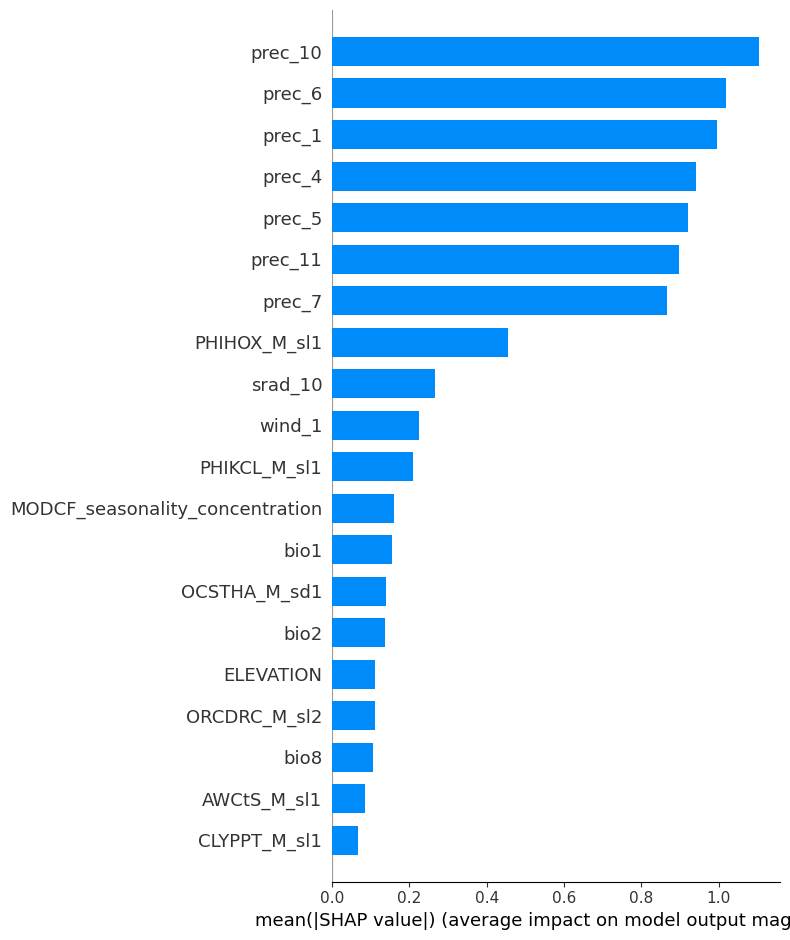

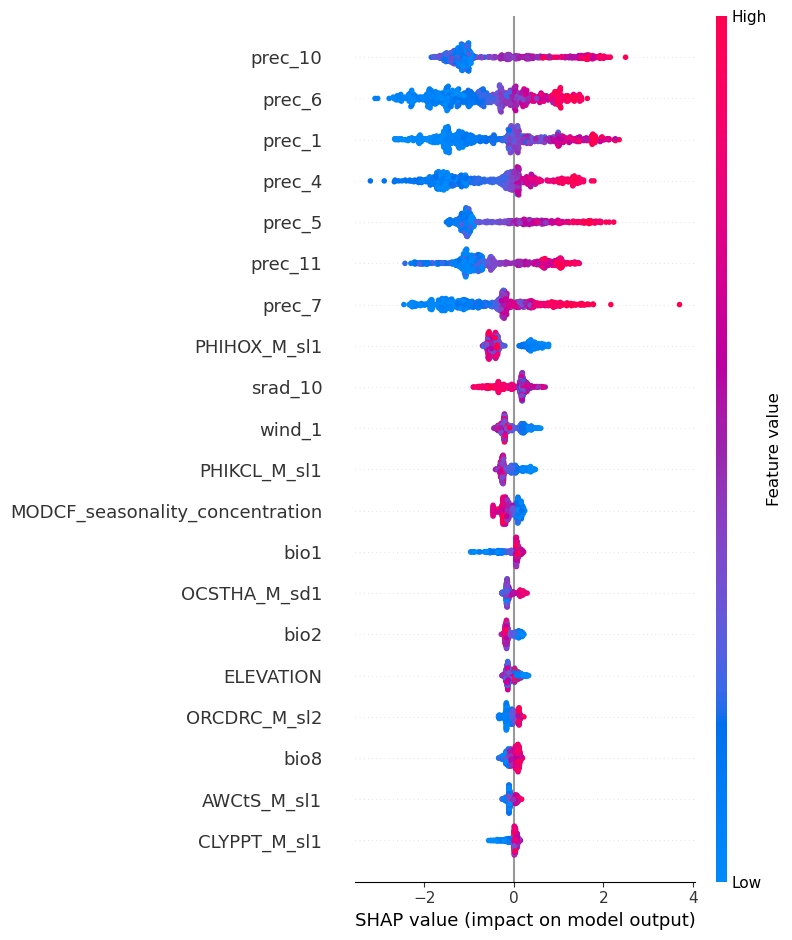

<Figure size 640x480 with 0 Axes>

In [25]:

import shap

# Explicador SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# --- 1. Importancia global ---
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# --- 2. Impacto de cada variable ---
shap.summary_plot(shap_values, X_test, show=True)
plt.savefig("./graficas/shap_summary_sequia.png", dpi=300)

El ranking de barras muestra el impacto medio absoluto de cada variable, cuanto mayor es la barra, mayor influencia tiene la variable en la predicción de resistencia a sequía. El orden está normalizado, por lo que **bio15** es la variable más influyente del modelo. **bio15** mide cuánta variación existe en la precipitación mensual promedio a lo largo del año, es decir, la desviación estandar de la precipitación mensual dividida por el promedio anual, multiplicada por 100.

| Ranking                                   | Variable                                   | Descripción                                                                                                                | Interpretación ecológica                                                                                       |
| ----------------------------------------- | ------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **1. prec_10**                            | Precipitación de octubre                   | Mes crucial de transición entre estaciones húmedas y secas; altos valores reflejan zonas con exceso de humedad prolongada. | ↑ Altas lluvias favorecen la resistencia; reflejan ambientes con saturación prolongada del suelo.              |
| **2. prec_6**                             | Precipitación de junio                     | Período de máxima pluviosidad en regiones tropicales; influye en la saturación del suelo.                                  | ↑ Refuerza la exposición a condiciones de anegamiento, promoviendo adaptaciones fisiológicas.                  |
| **3. prec_1**                             | Precipitación de enero                     | Determina condiciones de anegamiento temprano en el año.                                                                   | ↑ Accesiones de zonas con alta precipitación temprana presentan mayor tolerancia.                              |
| **4. prec_4 / prec_5 / prec_7 / prec_11** | Precipitaciones mensuales intermedias      | Indican continuidad del exceso hídrico durante varios meses del ciclo anual.                                               | ↑ La constancia de lluvias prolongadas selecciona genotipos con mecanismos de supervivencia al exceso de agua. |
| **8. PHIHOX_M_sl1**                       | pH del suelo (horizonte superficial)       | Suelos más ácidos suelen encontrarse en zonas con drenaje deficiente y acumulación de agua.                                | ↓ Valores bajos (ácidos) se asocian a ambientes anegados; mayor tolerancia en suelos mal drenados.             |
| **9. srad_10**                            | Radiación solar en octubre                 | Menor radiación → mayor nubosidad → persistencia de suelos saturados.                                                      | ↓ Alta radiación implica menor nubosidad y menor saturación del suelo.                                         |
| **10. wind_1**                            | Velocidad del viento                       | Menor viento = menor evaporación = mayor probabilidad de anegamiento.                                                      | ↓ Menor viento mantiene humedad alta; condiciones propicias para resistencia.                                  |
| **11. MODCF_seasonality_concentration**   | Concentración estacional de nubosidad      | Mayor concentración → periodos prolongados de nubosidad y lluvia.                                                          | ↑ Indica regiones con clima húmedo persistente, donde prosperan accesiones resistentes.                        |
| **12. bio1 / bio2 / bio8**                | Temperatura media anual y amplitud térmica | Valores bajos refuerzan ambientes fríos y húmedos.                                                                         | ↓ Menor temperatura y menor variabilidad térmica favorecen condici                                             |
                                                             |


El análisis SHAP revela que las precipitaciones mensuales son los factores más determinantes en la predicción de resistencia al anegamiento, especialmente durante los meses de octubre (prec_10), junio (prec_6) y enero (prec_1). Estos periodos corresponden a los picos y transiciones del régimen pluviométrico tropical, donde la saturación del suelo es más prolongada. El modelo asocia altos valores de precipitación con una mayor probabilidad de resistencia, lo que indica que las accesiones provenientes de regiones con lluvias persistentes tienden a haber desarrollado mecanismos de adaptación fisiológica y morfológica frente al exceso hídrico (por ejemplo, aerénquima o tolerancia hipoxigénica).

Por otra parte, las variables edáficas y atmosféricas como el pH superficial (PHIHOX_M_sl1), la radiación solar (srad_10), la velocidad del viento (wind_1) y la concentración estacional de nubosidad (MODCF_seasonality_concentration) complementan el patrón climático, describiendo condiciones de drenaje limitado, baja evaporación y alta retención de agua. Estas características definen ambientes típicos de zonas bajas, húmedas y con suelos arcillosos, donde la selección natural favorece genotipos de frijol con capacidad de sobrevivir y producir bajo condiciones de anoxia radicular.

En conjunto, el modelo XGBoost evidencia que la resistencia al anegamiento está fuertemente ligada a gradientes climáticos e hidrológicos, más que a la temperatura o altitud. Esta información resulta clave para estrategias FIGS (Focus Identification of Germplasm Strategy), ya que permite priorizar accesiones de regiones tropicales húmedas, con alta pluviosidad y baja radiación, como fuentes potenciales de alelos adaptativos a condiciones de encharcamiento prolongado.
## **************************************************************************************************************************************************************


## Distribución de probabilidades ##
la distribución de probabilidades predichas por modelo (violin plot) es una de las formas más potentes de visualizar la calibración y discriminación probabilística de los modelos.

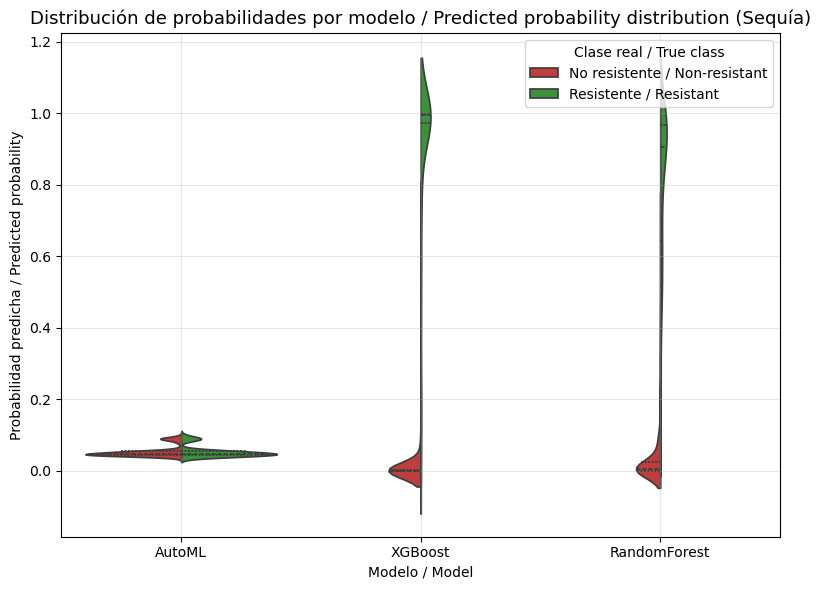

In [29]:
df_probs = resultados_sequia.copy()
df_probs["Clase_real"] = df_probs["y_true"].map({0: "No resistente / Non-resistant", 1: "Resistente / Resistant"})

plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_probs,
    x="modelo",
    y="y_proba",
    hue="Clase_real",
    split=True,
    inner="quart",
    palette=["#d62728", "#2ca02c"]
)
plt.title("Distribución de probabilidades por modelo / Predicted probability distribution (Sequía)", fontsize=13)
plt.xlabel("Modelo / Model")
plt.ylabel("Probabilidad predicha / Predicted probability")
plt.legend(title="Clase real / True class")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./graficas/distribucion_sequia.png", dpi=300)
plt.show()


### Interpretación ###
El gráfico anteriro tipo violín (Violin Plot) permite mostrar la distribución de las probabilidades predichas por cada modelo.

* El color rojo representa las accesiones *no resistentes* a anegamiento **(0)**.
* EL color verde representa las accesiones *resistentes* a anegamiento **(1)**.

## AutoML ##

Tanto las clases rojas (0) como verdes (1) se concentran en un rango muy estrecho, entre 0.03 y 0.1, lo que evidencia ausencia de separación entre ambas clases.
El modelo predice casi todas las accesiones con probabilidades bajas, sin distinguir adecuadamente las resistentes de las no resistentes.

Esto indica que AutoML no aprendió un patrón discriminante y que su salida se mantiene casi constante.
Es un comportamiento típico de un modelo subentrenado o sobreajustado a la clase dominante, que tiende a predecir siempre la categoría más frecuente (no resistente).

## XGBoost ##

El modelo XGBoost presenta una distribución bimodal y claramente separada:

* La clase no resistente (roja) se agrupa cerca de 0.0 – 0.1.
* La clase resistente (verde) se concentra alrededor de 0.9 – 1.0.

El solapamiento entre clases es mínimo, lo que refleja una excelente discriminación probabilística.
El modelo asigna altas probabilidades a las accesiones resistentes y bajas a las no resistentes, confirmando una calibración sólida y una alta capacidad predictiva.

Este patrón es coherente con sus métricas de desempeño (ROC-AUC ≈ 0.998 y PR-AUC ≈ 0.993), que evidencian una sensibilidad y precisión casi perfectas.

## Random Forest ##

Random Forest es casi identico al de XGBoost, aunque con mayor dispersión en la distribución.
Se observa un pequeño solapamiento entre clases en el rango intermedio (0.2 – 0.4), donde algunas accesiones presentan probabilidades no tan extremas.

Esto se debe a la naturaleza del algoritmo de ensamble donde algunos clasificadores individuales generan salidas más moderadas.
Aun así, el modelo conserva una discriminación muy alta, con accesiones resistentes concentradas hacia 1.0 y no resistentes hacia 0.0.

## Conclusión ##
El gráfico de distribución de probabilidades demuestra el grado de discriminación y calibración probabilística de los tres modelos frente a las clases reales de resistencia al anegamiento.

Primero, AutoML muestra una distribución estrecha en valores bajos (≈ 0.05), no hay preparación de clases, lo que representa la incapacidad del modelo para identificar accesiones resistentes.

En cambio, XGBoost y Random Forest presentan distribuciones bimodales y bien separadas: las accesiones resistentes (verde) se concentran cerca de 1.0, mientras las no resistentes (rojo) lo hacen cerca de 0.0.

Esta clara separación indica una alta capacidad de discriminación y buena calibración de probabilidades, consistente con los valores elevados de ROC-AUC (>0.99) y el bajo Brier Score (<0.03).
En conjunto, ambos modelos de árboles muestran rendimiento confiable y estable, siendo XGBoost el que logra la mejor separación entre clases y mayor precisión probabilística.